<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29421 entries, 0 to 29420
Data columns (total 37 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age_upon_outcome      29421 non-null  object 
 1   animal_id             29421 non-null  object 
 2   animal_type           29421 non-null  object 
 3   breed                 29421 non-null  object 
 4   color                 25795 non-null  object 
 5   date_of_birth         29421 non-null  object 
 6   datetime              29421 non-null  object 
 7   monthyear             29421 non-null  object 
 8   name                  16647 non-null  object 
 9   outcome_subtype       18641 non-null  object 
 10  outcome_type          29418 non-null  object 
 11  sex_upon_outcome      29421 non-null  object 
 12  count                 29421 non-null  int64  
 13  sex                   29421 non-null  object 
 14  Spay/Neuter           29421 non-null  object 
 15  Periods            

C:\Users\AyiGroup\AppData\Local\Temp\ipykernel_4172\1965646497.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TipoResultado', order=df['TipoResultado'].value_counts().index, palette='rocket_r')


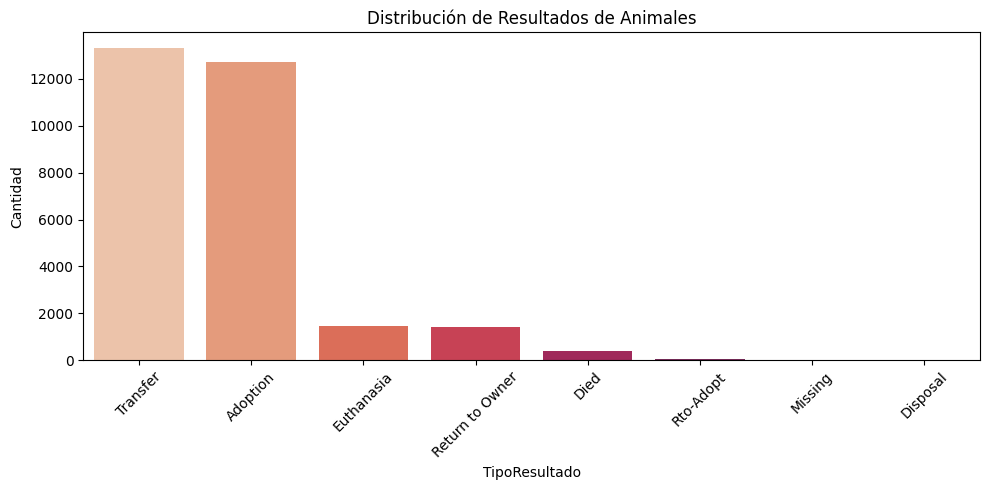

Distribución por Tipo de Animal:


C:\Users\AyiGroup\AppData\Local\Temp\ipykernel_4172\1965646497.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='TipoAnimal', order=df['TipoAnimal'].value_counts().index, palette='rocket_r')


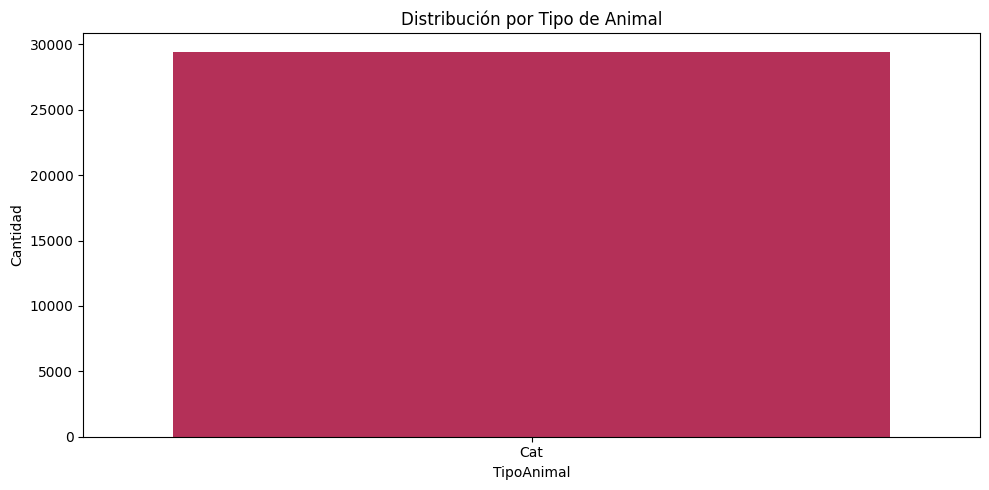

Distribución de Sexo por Tipo de Resultado del Animal:


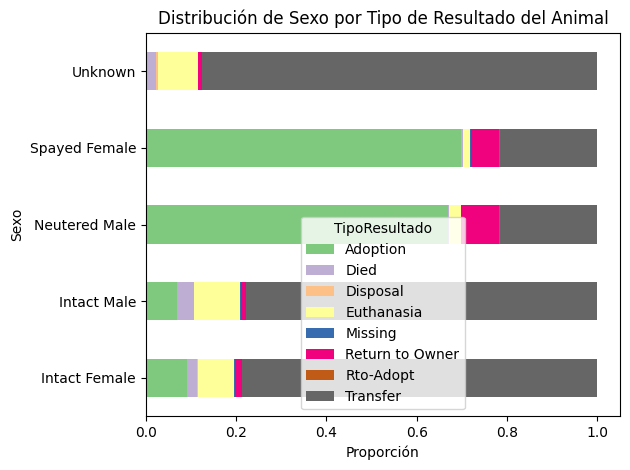

Edades de los animales al momento del resultado:


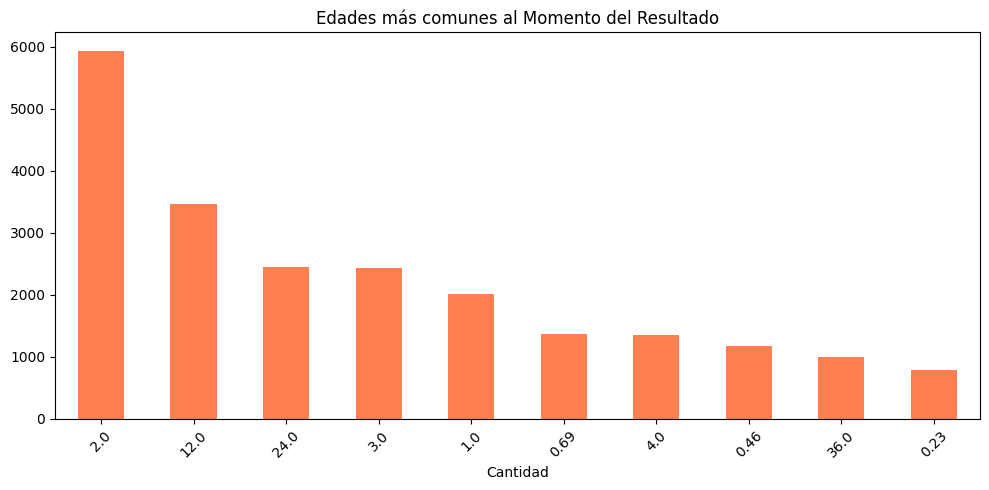

🐈 Total de gatos en el dataset: 29421


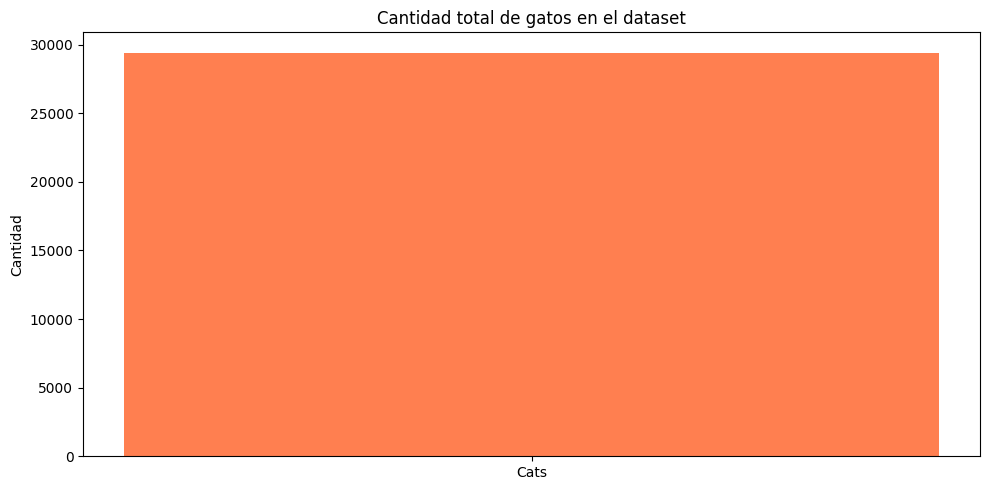

Top 5 Razas de Animales:


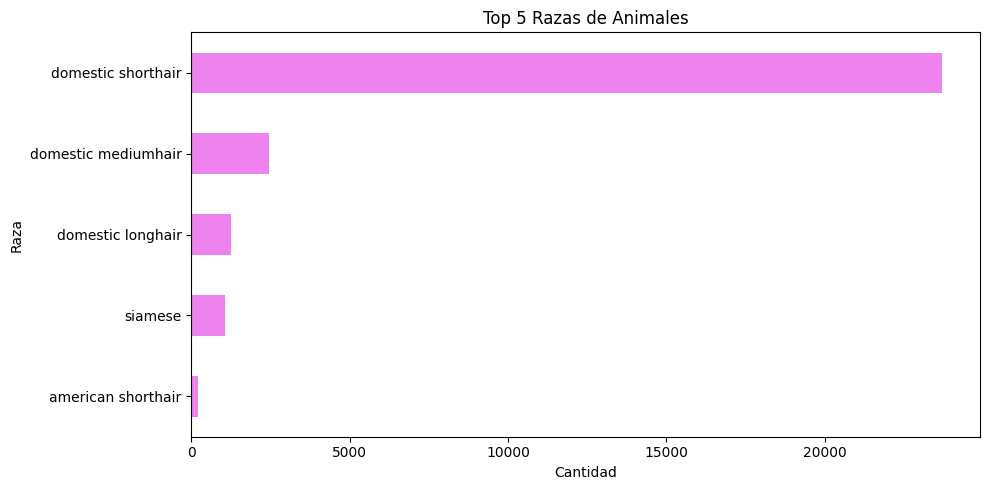

Proporción de animales con nombre:



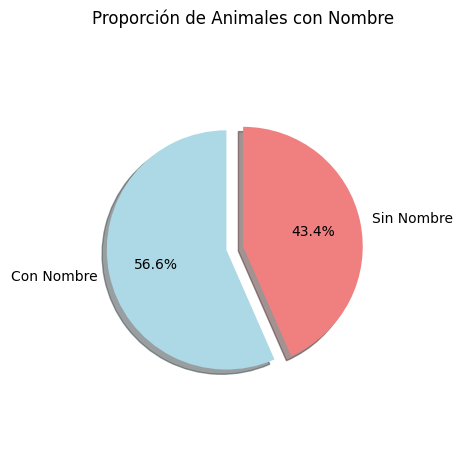

Resultados por raza dominante:



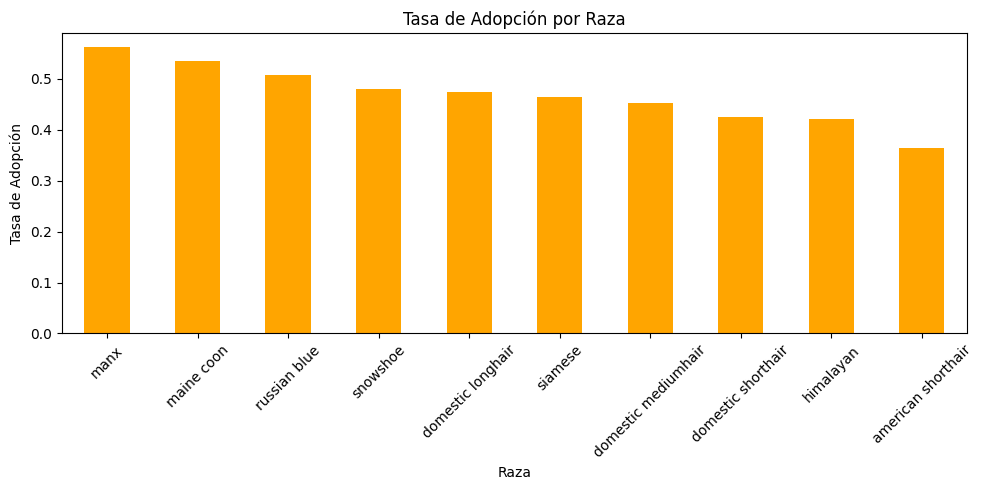

La edad más común al momento del resultado para los animales adoptados es: 2.0 

Nombres más comunes:


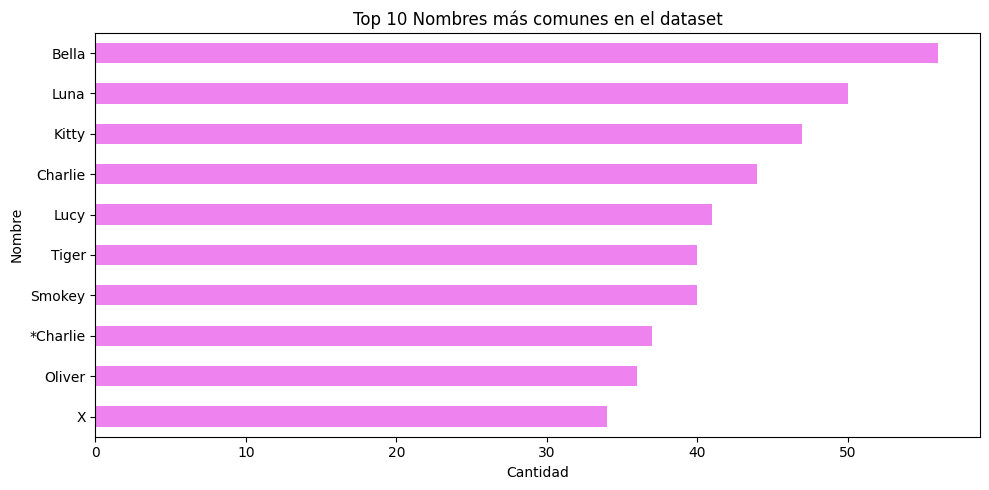

 Puros o mestizos
     Cruza  Cantidad
0  Mestizo     27491
1     Puro      1930
Tasa de adopción por año de nacimiento:


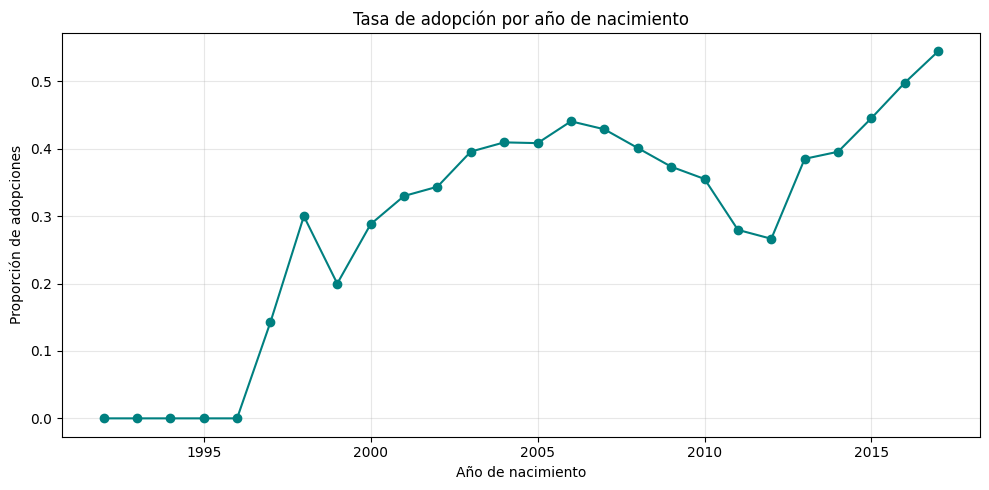

Relación edad por Tipo de Resultado


<Figure size 1200x600 with 0 Axes>

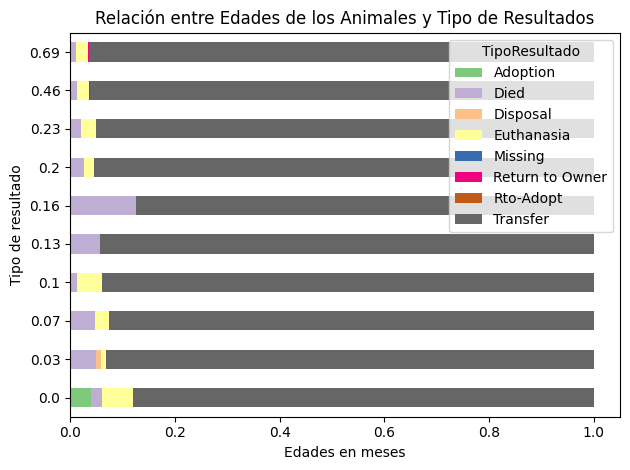

Archivo adoptados.csv guardado con éxito.


In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Cargar datos
df = pd.read_csv('aac_shelter_cat_outcome_eng.csv')
df.head()

# exploración
df.info()
df.describe(include='all')

# revisión de datos faltantes
df.isna().sum().sort_values(ascending=False)

# limpieza básica de datos
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# renombrar columnas
df = df.rename(columns = {
    'animal_id': 'ID',
    'name': 'Nombre',
    'date_of_birth': 'FechaNacimiento',
    'outcome_type': 'TipoResultado',
    'outcome_subtype': 'SubtipoResultado',
    'animal_type': 'TipoAnimal',
    'sex_upon_outcome': 'Sexo',
    'age_upon_outcome': 'Edad',
    'breed': 'Raza',
    'color': 'Color'
})
df.head()

#Normalizacion de edades a
def edad_a_meses(edad):
    if pd.isna(edad): return None
    edad = str(edad).lower()
    match = re.match(r'(\d+)\s*(year|month|week|day)s?', edad)
    if match:
        valor, unidad = int(match.group(1)), match.group(2)
        if unidad == 'year': return valor * 12
        if unidad == 'month': return valor
        if unidad == 'week': return round(valor * 12 / 52, 2)
        if unidad == 'day': return round(valor * 12 / 365, 2)
    return None

# distribución de resultados de animales
print("Distribución de resultados de animales:")
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='TipoResultado', order=df['TipoResultado'].value_counts().index, palette='rocket_r')
plt.title('Distribución de Resultados de Animales')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# que tipo de animales se registran con más frecuencia
print("Distribución por Tipo de Animal:")
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='TipoAnimal', order=df['TipoAnimal'].value_counts().index, palette='rocket_r')
plt.title('Distribución por Tipo de Animal')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

# relación entre el sexo y el resultado del animal
print("Distribución de Sexo por Tipo de Resultado del Animal:")

pd.crosstab(df['Sexo'], df['TipoResultado'], normalize='index').plot(kind='barh', stacked=True, colormap='Accent')
plt.title('Distribución de Sexo por Tipo de Resultado del Animal')
plt.xlabel('Proporción')
plt.ylabel('Sexo')
plt.tight_layout()
plt.show()

# edades de los animales al momento del resultado
print("Edades de los animales al momento del resultado:")
df['EdadMeses'] = df['Edad'].apply(edad_a_meses)
df['EdadMeses'].value_counts().head(10).plot(kind='bar', color='coral', figsize=(10,5))
plt.title('Edades más comunes al Momento del Resultado')
plt.xlabel('Cantidad')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#---------------------------------------------------------------#
## 🧪 Actividades prácticas y desafíos
# 1. **Filtrar por especie:** Mostrá sólo los registros correspondientes a gatos (`Cat`). ¿Cuántos hay en total?
plt.figure(figsize=(10,5))
df_cats = df[df['TipoAnimal'].str.lower() == 'cat']

print(f"🐈 Total de gatos en el dataset: {len(df_cats)}")
plt.bar(['Cats'], [len(df_cats)], color='coral')
plt.title('Cantidad total de gatos en el dataset')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()



# 2. **Top razas:** ¿Cuáles son las 5 razas más comunes en el dataset? Representalo en un gráfico de barras.
print("Top 5 Razas de Animales:")
plt.figure(figsize=(10,5))
ax =df['Raza'].value_counts().head(5).plot(kind='barh', color='violet')
plt.title('Top 5 Razas de Animales')
plt.xlabel('Cantidad')
plt.ylabel('Raza')
ax.invert_yaxis()  # Invertir el eje y para que la raza más común esté arriba
plt.tight_layout()
plt.show()



# 3. **Animales con nombre:** ¿Qué proporción de animales tiene nombre? Representalo con un gráfico de torta.
labels = ['Con Nombre', 'Sin Nombre']
df['Nombre'].notna().value_counts().plot(kind='pie', autopct='%1.1f%%', labels=labels, colors=['lightblue', 'lightcoral'], shadow=True, startangle=90, explode=(0.1, 0), radius=0.7)
print("Proporción de animales con nombre:")
plt.title('Proporción de Animales con Nombre')
plt.ylabel(' ')
plt.tight_layout()
plt.show()



# 4. **Resultados por raza dominante:** Analizá si hay razas que tienen mayores tasas de adopción. Filtrá las 10 razas más frecuentes y compará los resultados.
# top 10 razas más frecuentes
top_razas = df['Raza'].value_counts().head(10).index
df_top = df[df['Raza'].isin(top_razas)]
resumen = df_top.groupby('Raza').agg(
    total=('ID', 'count'),
    adoptados=('TipoResultado', lambda x: (x == 'Adoption').sum())
)
resumen['tasa_adopcion'] = resumen['adoptados'] / resumen['total']
resumen['tasa_adopcion'] = pd.to_numeric(resumen['tasa_adopcion'], errors='coerce')
resumen = resumen.dropna(subset=['tasa_adopcion'])
print("Resultados por raza dominante:")
plt.figure(figsize=(10,5))
resumen['tasa_adopcion'].sort_values(ascending=False).plot(kind='bar', color='orange')
plt.title('Tasa de Adopción por Raza')
plt.xlabel('Raza')
plt.ylabel('Tasa de Adopción')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



# 5. **Edad más común (modo):** ¿Cuál es la edad al momento del resultado más frecuente para los animales adoptados?
df['EdadMeses'] = df['Edad'].apply(edad_a_meses)
adoptados = df[df['TipoResultado'] == 'Adoption']
edad_mas_comun = adoptados['EdadMeses'].mode()[0] if not adoptados['EdadMeses'].mode().empty else None
print(f"La edad más común al momento del resultado para los animales adoptados es: {edad_mas_comun} \n")



# 6. **Nombres más comunes:** ¿Cuáles son los 10 nombres de animales más comunes en el dataset?
print("Nombres más comunes:")
plt.figure(figsize=(10,5))
ax =df['Nombre'].value_counts().head(10).plot(kind='barh', color='violet')
plt.title('Top 10 Nombres más comunes en el dataset')
plt.xlabel('Cantidad')
plt.ylabel('Nombre')
ax.invert_yaxis()  # Invertir el eje y para que la raza más común esté arriba
plt.tight_layout()
plt.show()



# 7. **Cruza o no cruza:** Agregá una nueva columna que indique si el animal es de raza pura o mestizo, en base a la columna de raza (`Raza`).
df['Cruza'] = df['Raza'].apply(lambda x: 'Puro' if 'domestic' not in x.lower() else 'Mestizo')
print(" Puros o mestizos")
df.head(5)

# Mostrar tabla resumen de puros y mestizos después de cualquier cambio
tabla_cruza = df['Cruza'].value_counts().reset_index()
tabla_cruza.columns = ['Cruza', 'Cantidad']
print(tabla_cruza)



# 8. **Tendencia de adopciones:** Convertí la columna de fecha de nacimiento a datetime y tratá de analizar si hay alguna relación entre el año de nacimiento y la probabilidad de adopción.
df['FechaNacimiento'] = pd.to_datetime(df['FechaNacimiento'], errors='coerce')
df['AñoNacimiento'] = df['FechaNacimiento'].dt.year
adopciones_por_año = df.groupby('AñoNacimiento')['TipoResultado'].apply(lambda x: (x == 'Adoption').mean())

print("Tasa de adopción por año de nacimiento:")
plt.figure(figsize=(10,5))
adopciones_por_año.plot(marker='o', color='teal')
plt.title('Tasa de adopción por año de nacimiento')
plt.xlabel('Año de nacimiento')
plt.ylabel('Proporción de adopciones')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# 9. **Relación entre edad y resultado:** Explorá si existe una diferencia en el tipo de resultado según la edad del animal.
# Normalizar 

df['EdadMeses'] =df['Edad'].apply(edad_a_meses)
print("Relación edad por Tipo de Resultado")
plt.figure(figsize=(12,6))
pd.crosstab(df['EdadMeses'], df['TipoResultado'], normalize='index').head(10).sort_index().plot(kind='barh', stacked=True, colormap='Accent')
plt.title('Relación entre Edades de los Animales y Tipo de Resultados')
plt.xlabel('Edades en meses')
plt.ylabel('Tipo de resultado')
plt.tight_layout()
plt.show()


# 10. **Exportar datos filtrados:** Filtrá los animales que fueron adoptados y guardalos en un nuevo archivo CSV llamado `adoptados.csv`.
adoptados = df[df['TipoResultado'] == 'Adoption']
adoptados.to_csv('adoptados.csv', index=False)
print('Archivo adoptados.csv guardado con éxito.')